In [22]:
# Install dependencies (Colab already has most, but let's ensure versions)
!pip install -q scikit-learn pandas numpy matplotlib seaborn joblib

In [2]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import joblib
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [3]:
# Load the California Housing Dataset
data = fetch_california_housing(as_frame=True)

# Combine features and target into one DataFrame
df = pd.concat([data.data, data.target.rename('MedHouseVal')], axis=1)

print("📦 Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print("\nFeature descriptions:")
for name, desc in zip(data.feature_names, data.DESCR.split('\n')[9:17]):
    print(f"  {name}: {desc.strip()}")

📦 Dataset loaded successfully!
Shape: (20640, 9)

Feature descriptions:
  MedInc: :Number of Attributes: 8 numeric, predictive attributes and the target
  HouseAge: 
  AveRooms: :Attribute Information:
  AveBedrms: - MedInc        median income in block group
  Population: - HouseAge      median house age in block group
  AveOccup: - AveRooms      average number of rooms per household
  Latitude: - AveBedrms     average number of bedrooms per household
  Longitude: - Population    block group population


In [4]:
# Exploratory Data Analysis - First Look
print("=" * 50)
print("FIRST 5 ROWS")
print("=" * 50)
display(df.head())

print("\n" + "=" * 50)
print("BASIC STATISTICS")
print("=" * 50)
display(df.describe().round(2))

print("\n" + "=" * 50)
print("MISSING VALUES")
print("=" * 50)
print(df.isnull().sum())
print("\n✅ No missing values!" if df.isnull().sum().sum() == 0 else "⚠️ Missing values found!")

FIRST 5 ROWS


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



BASIC STATISTICS


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00



MISSING VALUES
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

✅ No missing values!


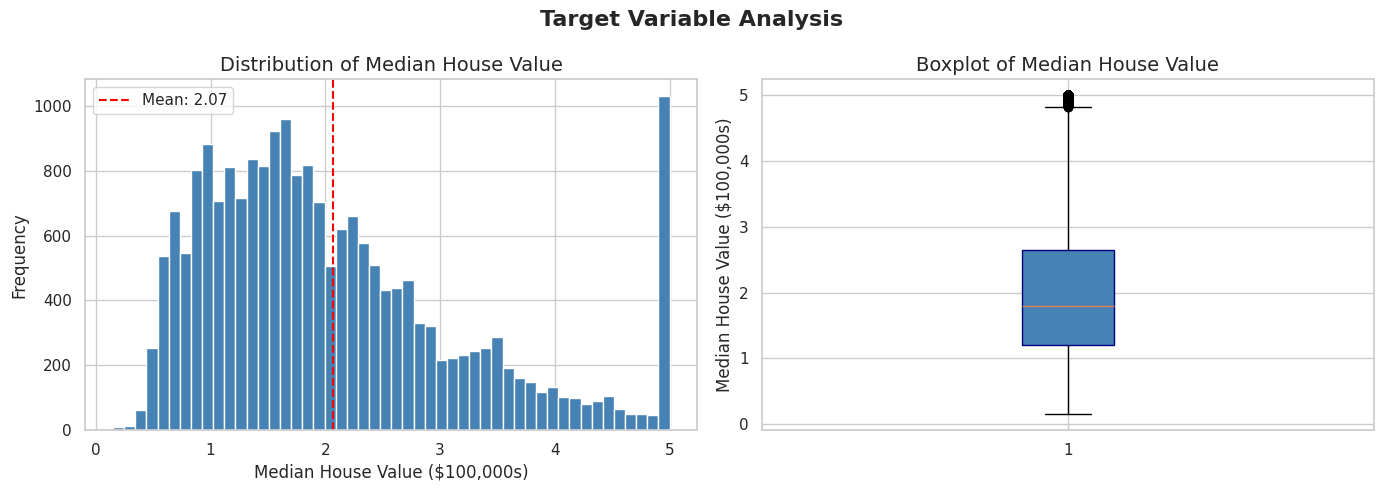


📊 Target Stats:
  Mean:   $206856
  Median: $179700
  Max:    $500001


In [5]:
# Distribution of Target Variable (Median House Value)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['MedHouseVal'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Median House Value', fontsize=14)
axes[0].set_xlabel('Median House Value ($100,000s)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['MedHouseVal'].mean(), color='red', linestyle='--', label=f"Mean: {df['MedHouseVal'].mean():.2f}")
axes[0].legend()

# Boxplot
axes[1].boxplot(df['MedHouseVal'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='navy'))
axes[1].set_title('Boxplot of Median House Value', fontsize=14)
axes[1].set_ylabel('Median House Value ($100,000s)')

plt.suptitle('Target Variable Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n📊 Target Stats:\n  Mean:   ${df['MedHouseVal'].mean()*100000:.0f}\n  Median: ${df['MedHouseVal'].median()*100000:.0f}\n  Max:    ${df['MedHouseVal'].max()*100000:.0f}")

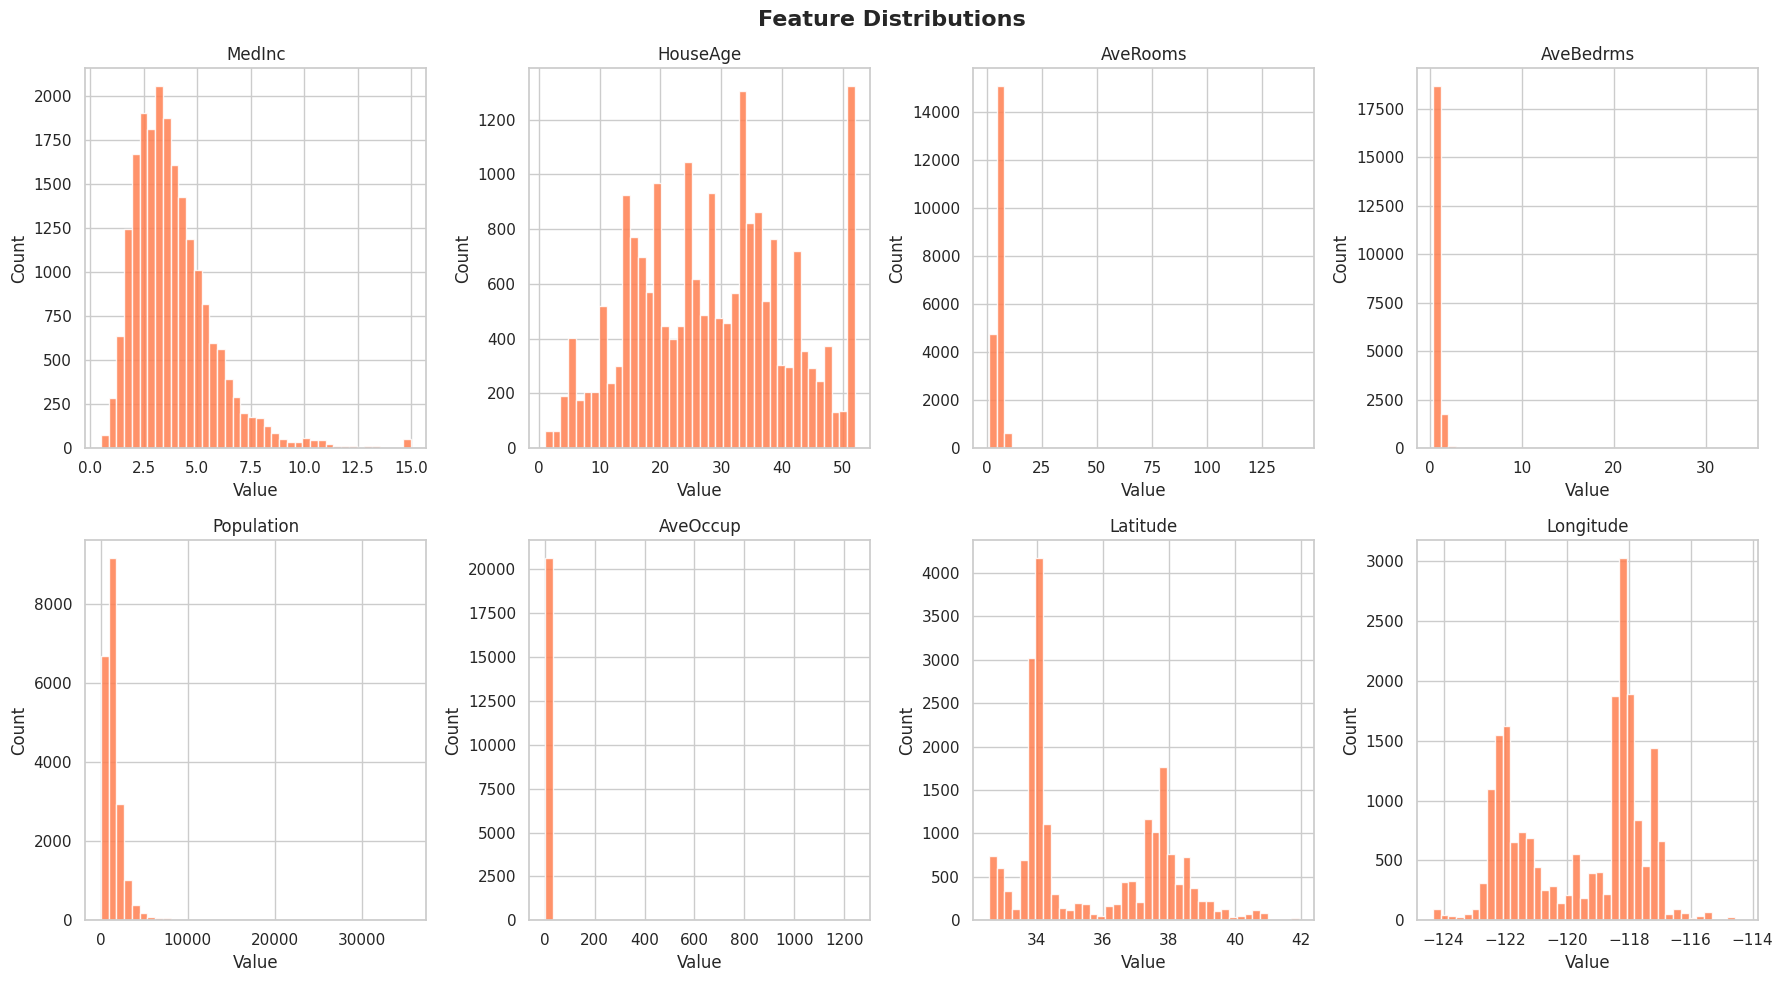

In [6]:
# Feature Distributions
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(data.feature_names):
    axes[i].hist(df[col], bins=40, color='coral', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

plt.suptitle('Feature Distributions', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

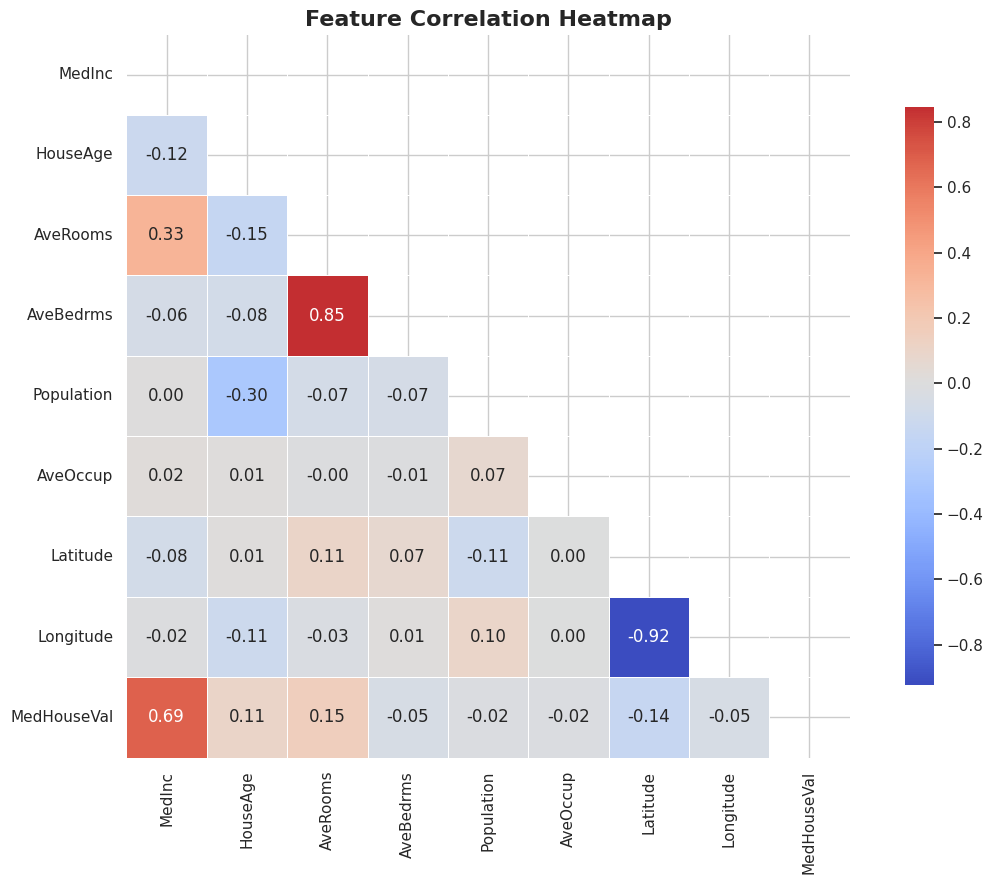


🔍 Top correlations with MedHouseVal:
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160


In [7]:
# Correlation Heatmap
plt.figure(figsize=(12, 9))
corr = df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n🔍 Top correlations with MedHouseVal:")
print(corr['MedHouseVal'].sort_values(ascending=False)[1:].to_string())

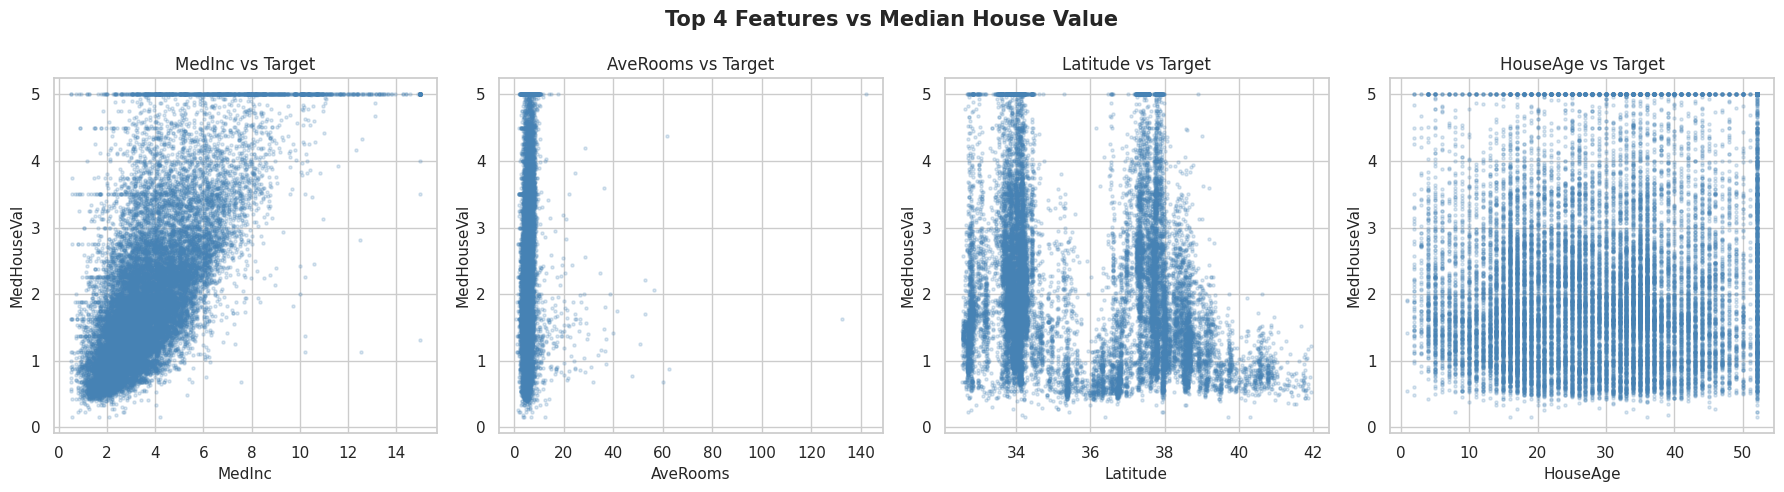

In [8]:
# Feature vs Target Scatter Plots (top 4 correlated)
top_features = corr['MedHouseVal'].abs().sort_values(ascending=False)[1:5].index.tolist()

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, feat in zip(axes, top_features):
    ax.scatter(df[feat], df['MedHouseVal'], alpha=0.2, color='steelblue', s=5)
    ax.set_xlabel(feat, fontsize=11)
    ax.set_ylabel('MedHouseVal', fontsize=11)
    ax.set_title(f'{feat} vs Target', fontsize=12)

plt.suptitle('Top 4 Features vs Median House Value', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_vs_target.png', dpi=150, bbox_inches='tight')
plt.show()

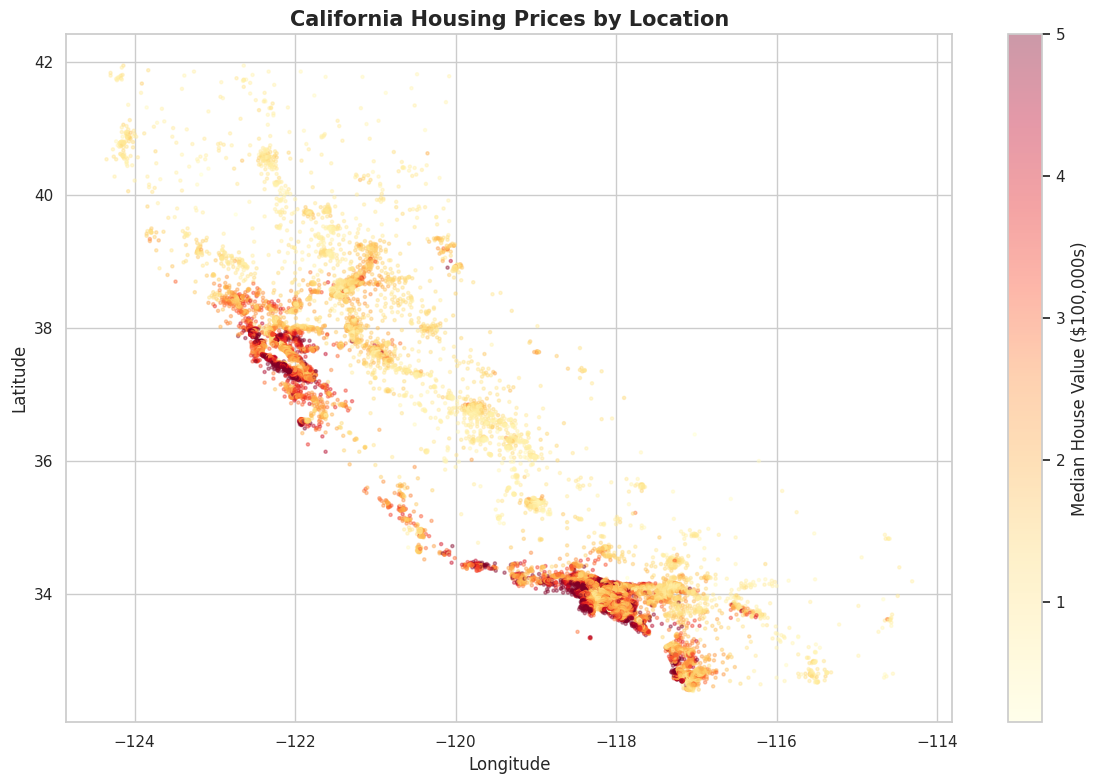

🗺️  Coastal areas (SF, LA) clearly show higher prices!


In [9]:
# Geographic distribution of house prices (Latitude vs Longitude)
plt.figure(figsize=(12, 8))
scatter = plt.scatter(df['Longitude'], df['Latitude'],
                      c=df['MedHouseVal'], cmap='YlOrRd',
                      alpha=0.4, s=5)
plt.colorbar(scatter, label='Median House Value ($100,000s)')
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.title('California Housing Prices by Location', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('geographic_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("🗺️  Coastal areas (SF, LA) clearly show higher prices!")

In [11]:
# Feature Engineering & Preprocessing

# Add useful derived features
df['RoomsPerHousehold'] = df['AveRooms'] / df['HouseAge'].replace(0, 1)
df['BedroomsPerRoom'] = df['AveBedrms'] / df['AveRooms'].replace(0, 1)
df['PopulationPerHousehold'] = df['Population'] / df['HouseAge'].replace(0, 1)

# Select final features
feature_cols = list(data.feature_names) + ['RoomsPerHousehold', 'BedroomsPerRoom', 'PopulationPerHousehold']
X = df[feature_cols]
y = df['MedHouseVal']

print(f"✅ Features used ({len(feature_cols)}): {feature_cols}")
print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

✅ Features used (11): ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'RoomsPerHousehold', 'BedroomsPerRoom', 'PopulationPerHousehold']

X shape: (20640, 11)
y shape: (20640,)


In [12]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"📊 Data Split Summary:")
print(f"  Training samples:   {X_train.shape[0]:,} ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"  Test samples:       {X_test.shape[0]:,} ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"  Number of features: {X_train.shape[1]}")

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("\n✅ Features scaled using StandardScaler!")

📊 Data Split Summary:
  Training samples:   16,512 (80%)
  Test samples:       4,128 (20%)
  Number of features: 11

✅ Features scaled using StandardScaler!


In [13]:
# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("🤖 Model trained successfully!")
print(f"\nModel intercept: {model.intercept_:.4f}")
print("\nFeature Coefficients:")
coeff_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)
display(coeff_df.reset_index(drop=True))

🤖 Model trained successfully!

Model intercept: 2.0719

Feature Coefficients:


,Feature,Coefficient
0,Latitude,-0.873936
1,Longitude,-0.853370
2,MedInc,0.847763
3,BedroomsPerRoom,0.202781
4,HouseAge,0.124004
5,AveBedrms,0.045424
6,AveOccup,-0.041296
7,AveRooms,0.039997
8,Population,-0.009907
9,PopulationPerHousehold,0.008338


In [16]:
# Model Evaluation
y_pred = model.predict(X_test_scaled)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("=" * 45)
print("        📈 MODEL EVALUATION METRICS")
print("=" * 45)
print(f"  MAE  (Mean Absolute Error)  : {mae:.4f}  (${mae*100000:,.0f})")
print(f"  RMSE (Root Mean Sq. Error)  : {rmse:.4f}  (${rmse*100000:,.0f})")
print(f"  R²   (Coefficient of Det.)  : {r2:.4f}  ({r2*100:.1f}% variance explained)")
print("=" * 45)

# Interpretation
print(f"""
📝 Interpretation:
  • On average, predictions are off by ~${mae*100000:,.0f}
  • The model explains {r2*100:.1f}% of the variance in house prices
  • RMSE of ${rmse*100000:,.0f} gives penalty for larger errors
""")

        📈 MODEL EVALUATION METRICS
  MAE  (Mean Absolute Error)  : 0.5260  ($52,601)
  RMSE (Root Mean Sq. Error)  : 0.7292  ($72,923)
  R²   (Coefficient of Det.)  : 0.5942  (59.4% variance explained)

📝 Interpretation:
  • On average, predictions are off by ~$52,601
  • The model explains 59.4% of the variance in house prices
  • RMSE of $72,923 gives penalty for larger errors



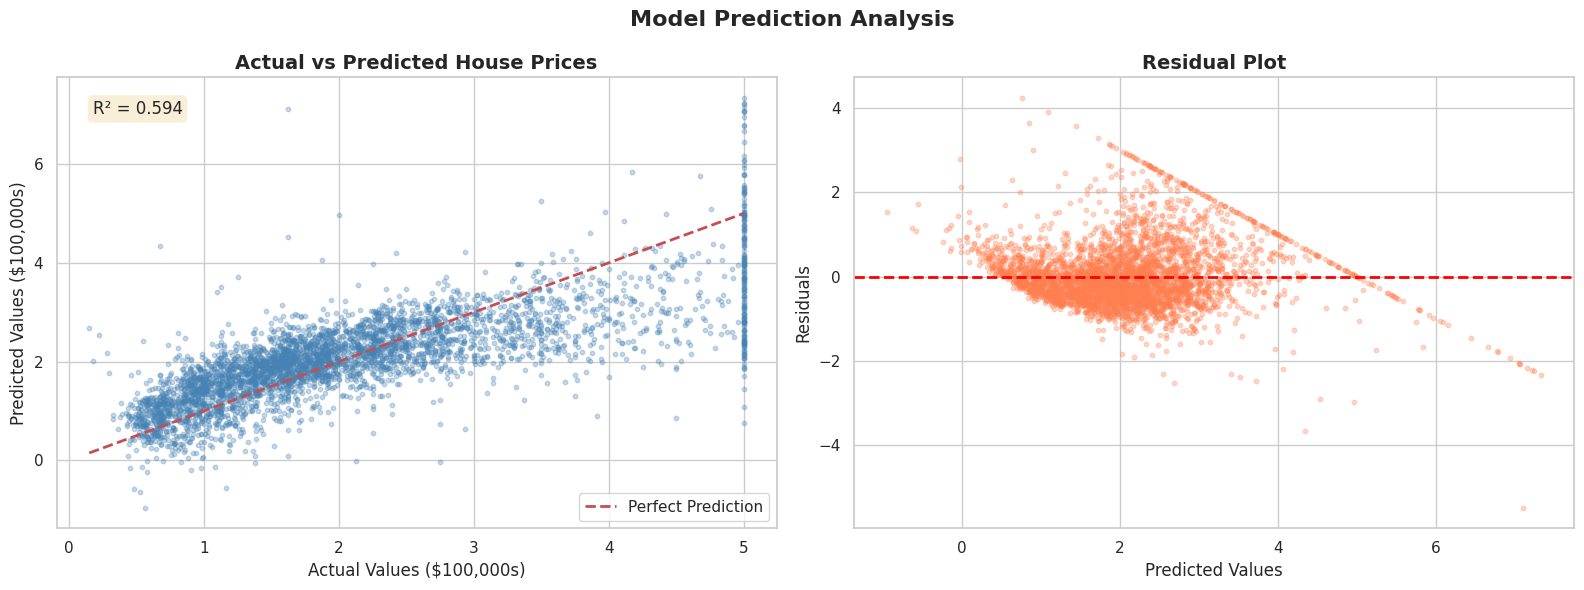

In [17]:
# Actual vs Predicted Scatter Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.3, color='steelblue', s=10)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Values ($100,000s)', fontsize=12)
axes[0].set_ylabel('Predicted Values ($100,000s)', fontsize=12)
axes[0].set_title('Actual vs Predicted House Prices', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].text(0.05, 0.95, f'R² = {r2:.3f}', transform=axes[0].transAxes,
             fontsize=12, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Residuals
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.3, color='coral', s=10)
axes[1].axhline(y=0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Values', fontsize=12)
axes[1].set_ylabel('Residuals', fontsize=12)
axes[1].set_title('Residual Plot', fontsize=14, fontweight='bold')

plt.suptitle('Model Prediction Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

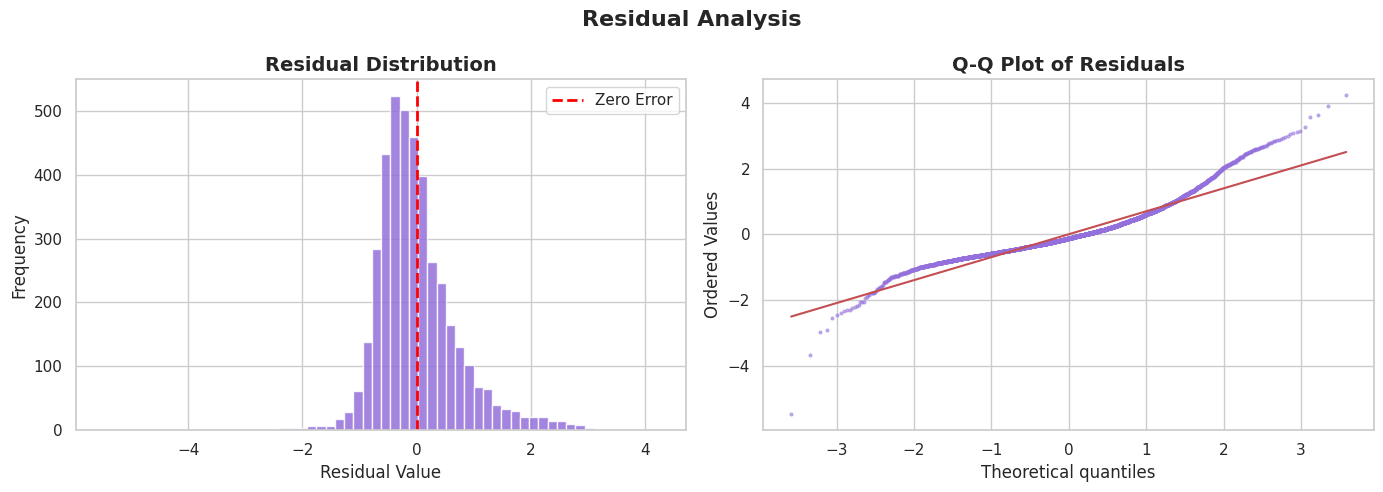

Residual mean: 0.0038 (should be ~0 for a good model)


In [18]:
# Residual Distribution Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of residuals
axes[0].hist(residuals, bins=60, color='mediumpurple', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='red', linestyle='--', lw=2, label='Zero Error')
axes[0].set_title('Residual Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Residual Value')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Q-Q plot (normality check)
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals', fontsize=14, fontweight='bold')
axes[1].get_lines()[0].set(markersize=2, alpha=0.5, color='mediumpurple')

plt.suptitle('Residual Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Residual mean: {residuals.mean():.4f} (should be ~0 for a good model)")

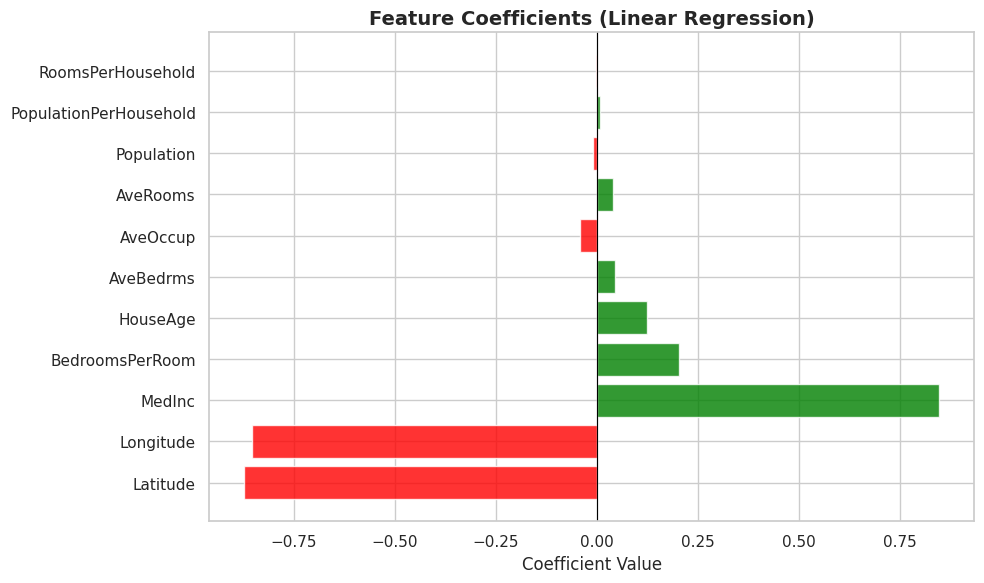

🟢 Green = positive effect on price | 🔴 Red = negative effect


In [19]:
# Feature Importance (by coefficient magnitude)
plt.figure(figsize=(10, 6))
colors = ['green' if c > 0 else 'red' for c in coeff_df['Coefficient']]
bars = plt.barh(coeff_df['Feature'], coeff_df['Coefficient'], color=colors, alpha=0.8)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel('Coefficient Value', fontsize=12)
plt.title('Feature Coefficients (Linear Regression)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("🟢 Green = positive effect on price | 🔴 Red = negative effect")

In [20]:
# Save Model and Scaler
joblib.dump(model, 'linear_regression_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("💾 Model saved as: linear_regression_model.pkl")
print("💾 Scaler saved as: scaler.pkl")

# Download files in Colab
from google.colab import files
files.download('linear_regression_model.pkl')
files.download('scaler.pkl')

💾 Model saved as: linear_regression_model.pkl
💾 Scaler saved as: scaler.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
# Predict on New House Input
def predict_house_price(MedInc, HouseAge, AveRooms, AveBedrms,
                         Population, AveOccup, Latitude, Longitude):
    """Predict California house price given feature inputs."""
    # Derived features
    RoomsPerHousehold     = AveRooms / max(HouseAge, 1)
    BedroomsPerRoom       = AveBedrms / max(AveRooms, 1)
    PopulationPerHousehold = Population / max(HouseAge, 1)

    input_data = pd.DataFrame([[MedInc, HouseAge, AveRooms, AveBedrms,
                                 Population, AveOccup, Latitude, Longitude,
                                 RoomsPerHousehold, BedroomsPerRoom, PopulationPerHousehold]],
                               columns=feature_cols)

    input_scaled = scaler.transform(input_data)
    prediction   = model.predict(input_scaled)[0]
    return prediction * 100_000  # Convert to dollars

# Example: A house in San Francisco area
price = predict_house_price(
    MedInc=5.0,       # Median income (in $10,000s)
    HouseAge=20,      # Age of house
    AveRooms=6.0,     # Average rooms
    AveBedrms=1.2,    # Average bedrooms
    Population=1500,  # Block population
    AveOccup=3.0,     # Average occupancy
    Latitude=37.77,   # SF latitude
    Longitude=-122.42 # SF longitude
)

print(f"🏡 Predicted House Price: ${price:,.0f}")
print(f"   (That's ${price/100000:.2f} in the dataset's unit of $100,000s)")

🏡 Predicted House Price: $279,756
   (That's $2.80 in the dataset's unit of $100,000s)
